# Supervised Learning
## 2.1 Classical ML Models (Logistic Regression & Gradient Boosted Tree)
We decided to mostly use the last-measured value as input feature as this the closest to death and should be most informative. The 4 static values will be kept (for static weight this is the first).

In [ ]:
# Simple Feature Prepro
# For each patient: last-measured value of each dynamic variable + static variables

import numpy as np
import pandas as pd
import pickle

# ── Load processed (scaled, imputed) data ────────────────────────────────────
df_train = pd.read_parquet("processed/set_a_processed.parquet")
df_val   = pd.read_parquet("processed/set_b_processed.parquet")
df_test  = pd.read_parquet("processed/set_c_processed.parquet")

DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight']
ALL_FEATURES = DYNAMIC_VARS + STATIC_VARS  # 41 features total

def extract_simple_features(df):
    """
    Per patient:
      - Dynamic variables: take the last-measured value (hour 48 row after ffill)
      - Static variables: take as-is (constant across hours)
    Returns one row per patient with features + label.
    """
    last_row = df.sort_values(["RecordID", "hour"]).groupby("RecordID").last().reset_index()
    
    features = last_row[["RecordID"] + ALL_FEATURES].copy()
    labels   = last_row[["RecordID", "In-hospital_death"]].copy()
    
    return features, labels

X_train, y_train = extract_simple_features(df_train)
X_val,   y_val   = extract_simple_features(df_val)
X_test,  y_test  = extract_simple_features(df_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"\nTrain mortality rate: {y_train['In-hospital_death'].mean():.3f}")
print(f"Val   mortality rate: {y_val['In-hospital_death'].mean():.3f}")
print(f"Test  mortality rate: {y_test['In-hospital_death'].mean():.3f}")
print(f"\nNaN in X_train: {X_train[ALL_FEATURES].isna().sum().sum()}")
X_train.head()

In [13]:
# ── Logistic Regression ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve, precision_recall_curve)

# Prepare arrays (drop RecordID)
X_tr = X_train[FEATURE_COLS].values
X_v  = X_val[FEATURE_COLS].values
X_te = X_test[FEATURE_COLS].values
y_tr = y_train["In-hospital_death"].values
y_v  = y_val["In-hospital_death"].values
y_te = y_test["In-hospital_death"].values

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_tr, y_tr)

lr_proba_val  = lr.predict_proba(X_v)[:, 1]
lr_proba_test = lr.predict_proba(X_te)[:, 1]

print("=== Logistic Regression (default) ===")
print(f"Val  AUROC: {roc_auc_score(y_v, lr_proba_val):.4f}  |  AUPRC: {average_precision_score(y_v, lr_proba_val):.4f}")
print(f"Test AUROC: {roc_auc_score(y_te, lr_proba_test):.4f}  |  AUPRC: {average_precision_score(y_te, lr_proba_test):.4f}")

=== Logistic Regression (default) ===
Val  AUROC: 0.8482  |  AUPRC: 0.5183
Test AUROC: 0.8417  |  AUPRC: 0.4914


In [14]:
# ── Gradient Boosted Tree ────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
)
gbt.fit(X_tr, y_tr)

gbt_proba_val  = gbt.predict_proba(X_v)[:, 1]
gbt_proba_test = gbt.predict_proba(X_te)[:, 1]

print("=== Gradient Boosted Tree ===")
print(f"Val  AUROC: {roc_auc_score(y_v, gbt_proba_val):.4f}")
print(f"Test AUROC: {roc_auc_score(y_te, gbt_proba_test):.4f}")
print(f"\nVal classification report (threshold=0.5):")
print(classification_report(y_v, (gbt_proba_val >= 0.5).astype(int), target_names=["Survived", "Died"]))

=== Gradient Boosted Tree ===
Val  AUROC: 0.8474
Test AUROC: 0.8443

Val classification report (threshold=0.5):
              precision    recall  f1-score   support

    Survived       0.90      0.96      0.93      3432
        Died       0.58      0.33      0.42       568

    accuracy                           0.87      4000
   macro avg       0.74      0.65      0.68      4000
weighted avg       0.85      0.87      0.86      4000

=== Gradient Boosted Tree ===
Val  AUROC: 0.8474
Test AUROC: 0.8443

Val classification report (threshold=0.5):
              precision    recall  f1-score   support

    Survived       0.90      0.96      0.93      3432
        Died       0.58      0.33      0.42       568

    accuracy                           0.87      4000
   macro avg       0.74      0.65      0.68      4000
weighted avg       0.85      0.87      0.86      4000



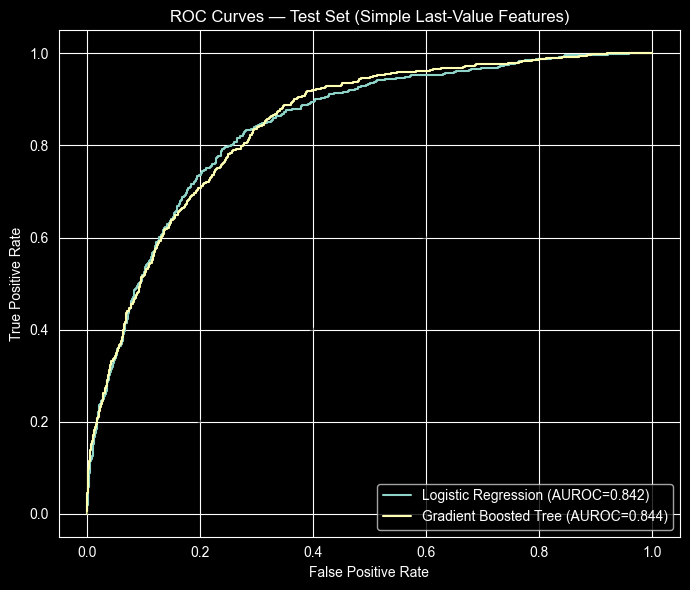

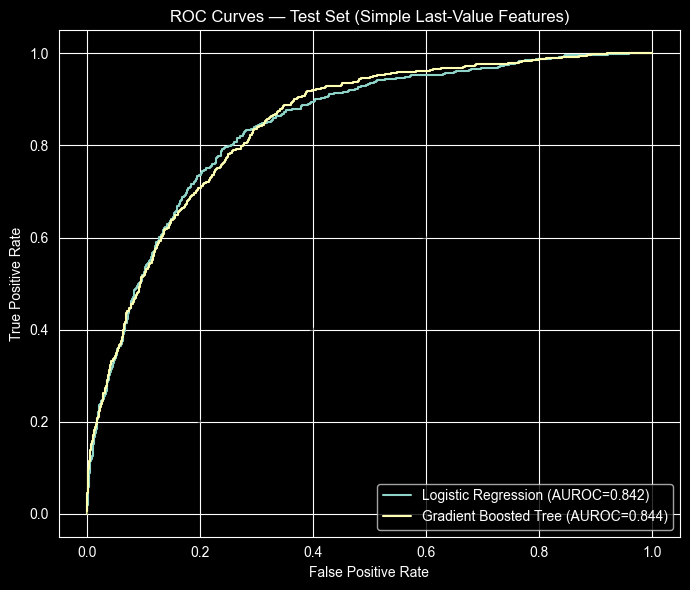

In [15]:
# ── Compare models ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

for name, proba in [("Logistic Regression", lr_proba_test), ("Gradient Boosted Tree", gbt_proba_test)]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set (Simple Last-Value Features)")
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 Hyperparameter Tuning with GridSearchCV
We use 5-fold stratified cross-validation on the training set, optimizing for AUROC.

In [16]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression Grid Search ─────────────────────────────────────────
lr_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["saga"],
    "class_weight": ["balanced", None],
}

lr_gs = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
lr_gs.fit(X_tr, y_tr)

print(f"\n=== Logistic Regression — Best Params ===")
print(lr_gs.best_params_)
print(f"Best CV AUROC: {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its defau


=== Logistic Regression — Best Params ===
{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best CV AUROC: 0.8290
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-pack


=== Logistic Regression — Best Params ===
{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best CV AUROC: 0.8290


In [10]:
# ── Gradient Boosted Tree Grid Search ────────────────────────────────────────
gbt_param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "min_samples_leaf": [5, 10, 20],
}

gbt_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gbt_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
gbt_gs.fit(X_tr, y_tr)

print(f"\n=== Gradient Boosted Tree — Best Params ===")
print(gbt_gs.best_params_)
print(f"Best CV AUROC: {gbt_gs.best_score_:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

=== Gradient Boosted Tree — Best Params ===
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 100, 'subsample': 0.7}
Best CV AUROC: 0.8552
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


Model             Val AUROC   Val AUPRC   Test AUROC   Test AUPRC
-----------------------------------------------------------------
LR (tuned)           0.8501      0.5253       0.8457       0.5007
GBT (tuned)          0.8502      0.5204       0.8495       0.5270


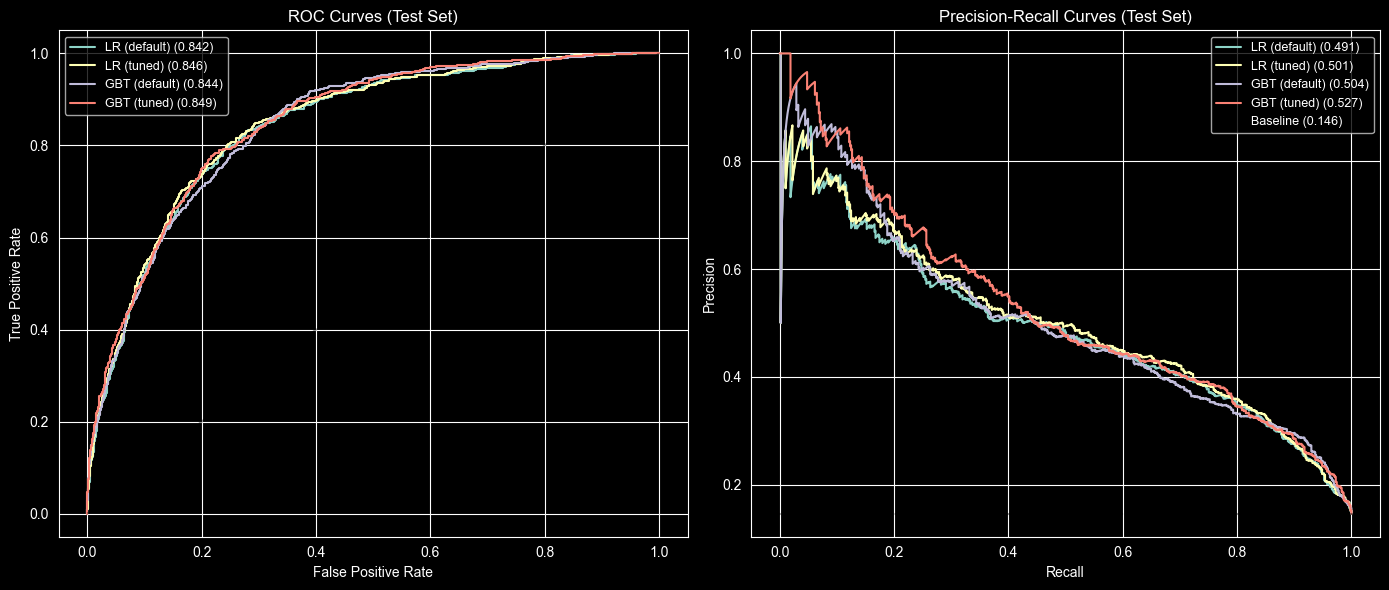

In [11]:
# ── Evaluate tuned models on val & test ──────────────────────────────────────
from sklearn.metrics import average_precision_score, precision_recall_curve

lr_best  = lr_gs.best_estimator_
gbt_best = gbt_gs.best_estimator_

results = {}
print(f"{'Model':15s}  {'Val AUROC':>10s}  {'Val AUPRC':>10s}  {'Test AUROC':>11s}  {'Test AUPRC':>11s}")
print("-" * 65)
for name, model in [("LR (tuned)", lr_best), ("GBT (tuned)", gbt_best)]:
    p_val  = model.predict_proba(X_v)[:, 1]
    p_test = model.predict_proba(X_te)[:, 1]
    auc_val  = roc_auc_score(y_v, p_val)
    auc_test = roc_auc_score(y_te, p_test)
    prc_val  = average_precision_score(y_v, p_val)
    prc_test = average_precision_score(y_te, p_test)
    results[name] = {"val_auc": auc_val, "test_auc": auc_test,
                     "val_prc": prc_val, "test_prc": prc_test, "proba_test": p_test}
    print(f"{name:15s}  {auc_val:10.4f}  {prc_val:10.4f}  {auc_test:11.4f}  {prc_test:11.4f}")

# ── ROC & PRC comparison: default vs tuned ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

curves = [
    ("LR (default)",  lr_proba_test),
    ("LR (tuned)",    results["LR (tuned)"]["proba_test"]),
    ("GBT (default)", gbt_proba_test),
    ("GBT (tuned)",   results["GBT (tuned)"]["proba_test"]),
]

# ROC
for name, proba in curves:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Test Set)")
axes[0].legend(fontsize=9)

# PRC
baseline_prc = y_te.mean()
for name, proba in curves:
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    axes[1].plot(rec, prec, label=f"{name} ({ap:.3f})")
axes[1].axhline(baseline_prc, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline_prc:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (Test Set)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()